In [1]:
#| default_exp user_guide

## Models zoo

The table below lists the models along with their descriptions and usage examples.

### Univariate forecasters

| **Models** | **Description** | **Usage Example** |
|----------|-----------|---------------|
| Naive Forecaster | A simple forecasting model that uses the last observed value or last seasonal value as the forecast. | <code> from peshbeen.models import naive <br> model = naive(target_col='target column name', season_period=None) <br> model.fit(df) <br> forecasts = model.forecast(H=10)|
| ETS (Exponential Smoothing state space models) | ETS forecaster that wraps the `statsmodels` implementation, allowing for easy integration and forecasting. | <code> from peshbeen.models import ets <br> model = ets(target_col='target column name', trend='add', seasonal='add', seasonal_periods=12, smoothing_level=0.1, smoothing_trend=0.1, smoothing_seasonal=0.1) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| ARIMA (AutoRegressive Integrated Moving Average) | ARIMA — a fast, familiar forecaster backed by Nixtla's `statsforecast` implementation, the fastest ARIMA in Python. | <code> from peshbeen.models import arima <br> model = arima(target_col='target column name', order=(1, 1, 1)) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| Machine Learning Regressors — any scikit-learn-compatible regressor, from LinearRegression, RandomForest and AdaBoost to XGBoost, LightGBM, and CatBoost. | A unified forecasting wrapper for any compatible regression model. | <code> from peshbeen.models import ml_forecaster <br> from sklearn.ensemble import RandomForestRegressor <br> model = ml_forecaster(target_col='target column name', estimator=RandomForestRegressor(n_estimators=100)) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| MS-ARR (Markov-Switching AutoRegressive Regression) | Models time series with hidden regime changes (e.g. recession vs. growth, low vs. high volatility) using autoregressive dynamics and optional exogenous variables. | <code>  from peshbeen.models import ms_arr <br> model = ms_arr(target_col='target column name', n_components=2, lags = 2, n_iter=100) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| GLM (Generalized Linear Models) | A statsmodels-backed generalization of linear regression that supports non-Gaussian response distributions — including Poisson for count data and Gamma for strictly positive, skewed data. | <code> from peshbeen.models import glm <br> model = glm(target_col='target column name', family='poisson', lags=2) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |

### Multivariate forecasters

| **Models** | **Description** | **Usage Example** |
|----------|-----------|---------------|
| VAR (Vector AutoRegression) | A pure-NumPy multivariate forecaster that models linear interdependencies across multiple time series, with per-series lag structure control. | <code> from peshbeen.models import var <br> model = var(target_cols=['target column 1', 'target column 2'], lags={'target column 1': 2, 'target column 2': [1, 2, 7]}) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| Machine Learning Regressors (multivariate) — any scikit-learn-compatible regressor, from LinearRegression and RandomForest to XGBoost, LightGBM, and CatBoost. | Forecasts multiple series simultaneously by leveraging interdependencies among them, using any scikit-learn-compatible regressor. | <code> from peshbeen.models import ml_mv_forecaster <br> from lightgbm import LGBMRegressor <br> model = ml_mv_forecaster(target_cols=['target column 1', 'target column 2'], estimator=LGBMRegressor(n_estimators=100, learning_rate=0.1), lags={'target column 1': 2, 'target column 2': [1, 2, 7]}) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| MS-VAR (Markov-Switching Vector AutoRegression) | A multivariate extension of MS-ARR that models multiple time series with hidden regime changes using vector autoregressive dynamics and optional exogenous variables. | <code> from peshbeen.models import ms_var <br> model = ms_var(target_cols=['target column 1', 'target column 2'], n_components=2, lags={'target column 1': 2, 'target column 2': [1, 2, 7]}, n_iter=100) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |

## Stationarity & Detrending Strategies

**What is stationarity?**

Stationarity is a fundamental concept in time series analysis that refers to the statistical properties of a time series being constant over time. A stationary time series has a constant mean, variance, and autocorrelation structure, which allows for more reliable modeling and forecasting. Non-stationary time series, on the other hand, exhibit trends, seasonality, or changing variance, making them more challenging to model accurately.

**Why is stationarity important?**

Many forecasting models, especially traditional statistical models like ARIMA and Machine Learning Regressors, assume that the underlying time series is stationary. If the data is non-stationary, these models may produce biased or inaccurate forecasts. By ensuring stationarity through techniques like differencing and detrending, we can improve the performance of these models and obtain more reliable forecasts.

The time series below is non-stationary, with an upward trend and weekly seasonality. We will use this time series to demonstrate how to apply different forecasting models, such as ETS, ARIMA, and Machine Learning models.

In [2]:
#| hide
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = "#FBFAF4"
plt.rcParams['axes.facecolor'] = "#FBFAF4"

# dont show warnings
import warnings
warnings.filterwarnings("ignore")

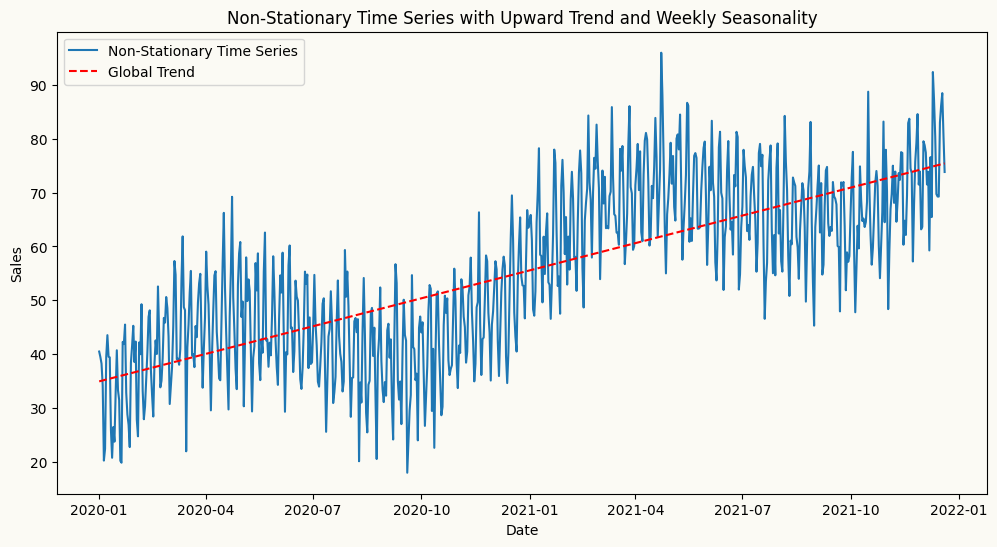

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
date_range = pd.date_range(start='2020-01-01', periods=720, freq='D')
# create a non-stationary arbitrary flower sales data with an upward trend, weekly seasonality, and yearly seasonality
np.random.seed(42)
data = 30 + 0.07 * np.arange(720) + 10 * np.sin(2 * np.pi * date_range.dayofyear / 7) + 10 * np.sin(2 * np.pi * date_range.dayofyear / 365) + np.random.normal(0, 5, 720)

sales_data = pd.DataFrame(data, index=date_range, columns=['sales'])

# plot trend line using linear regression
from sklearn.linear_model import LinearRegression
X = np.arange(len(sales_data)).reshape(-1, 1)
y = sales_data['sales'].values
model = LinearRegression()
model.fit(X, y)
trend_line = model.predict(X)


plt.figure(figsize=(12, 6))
plt.plot(sales_data.index, sales_data['sales'], label='Non-Stationary Time Series')
plt.plot(sales_data.index, trend_line, label='Global Trend', color='red', linestyle='--')
plt.title('Non-Stationary Time Series with Upward Trend and Weekly Seasonality')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()


In [4]:
#| hide

## Create and ARIMA(2,1,1) time series
from statsmodels.tsa.arima_process import ArmaProcess
arparams = np.array([.75, -.25])
maparams = np.array([.65, .35])
ar = np.r_[1, -arparams] # add zero-lag and negate
ma = np.r_[1, maparams] # add zero-lag
arma_process = ArmaProcess(ar, ma)
arma_data = arma_process.generate_sample(nsample=720)
arma_data = np.cumsum(arma_data)  # Integrate to make it ARIMA(2,1,1)
arma_data += 30 + 10 * np.sin(2 * np.pi * date_range.dayofyear / 7) + 10 * np.sin(2 * np.pi * date_range.dayofyear / 365) + np.random.normal(0, 1, 720)  # Add trend and seasonality
arma_sales_data = pd.DataFrame(arma_data, index=date_range, columns=['Value'])

Here, we forecast the same series using multiple models — starting with ETS, which handles non-stationary data natively, then ARIMA and ML regressors, where peshbeen's built-in detrending and transformation pipeline takes care of stationarity automatically.

**ETS Example**

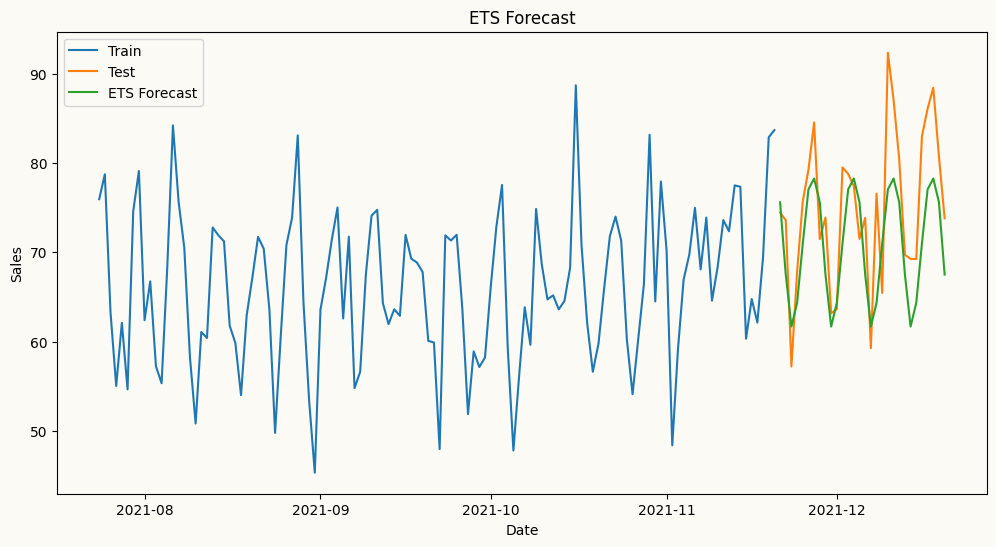

In [5]:

from lightgbm import LGBMRegressor
train = sales_data.iloc[:-30]
test = sales_data.iloc[-30:]
from peshbeen.models import ets, arima, ml_forecaster
ets_model = ets(target_col='sales', seasonal = 'additive', seasonal_periods=7)
ets_model.fit(train)
ets_forecast = ets_model.forecast(H=30)
# plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index[-120:], train['sales'][-120:], label='Train')
plt.plot(test.index, test['sales'], label='Test')
plt.plot(test.index, ets_forecast, label='ETS Forecast')
plt.title('ETS Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

**ARIMA Example**

Arima automatically applies differencing to make the series stationary by specifying the order of differencing (d) in the model parameters. In this example, we set d=1 to apply first-order differencing, which helps to remove the trend and make the series stationary for ARIMA modeling. To guide lag selection, we can also visualize the ACF and PACF plots of the original series to identify the ideal number of autoregressive (p) and moving average (q) terms for the ARIMA model. The ACF plot helps to identify the number of MA terms, while the PACF plot helps to identify the number of AR terms. As shown in the plots below, the ACF plot exhibits a slow decay, indicating non-stationarity, while the PACF plot shows significant spikes at lags 1 and 2, suggesting that an AR(2) model may be appropriate for the ARIMA model.

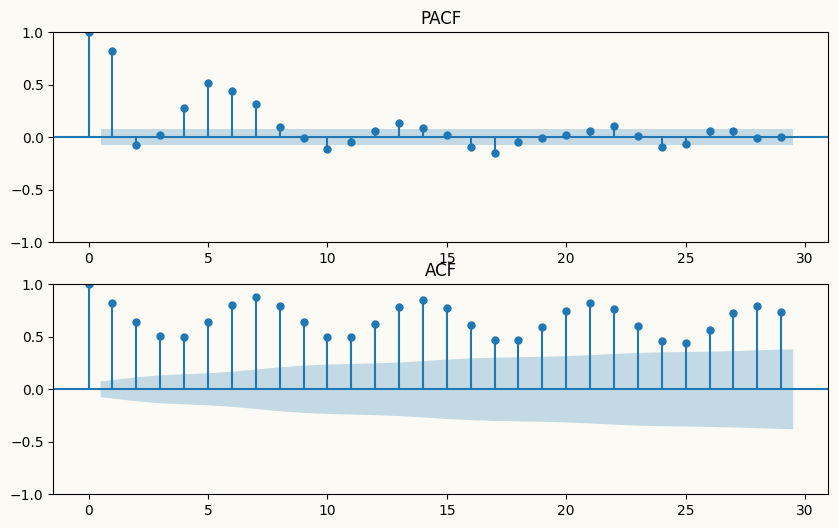

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plot_pacf(train["sales"], ax=axes[0], title="PACF")
plot_acf(train["sales"], ax=axes[1], title="ACF")
plt.show()

### Trend removal via differencing

Let's see how the forecasts look when doesn't apply differencing for ARIMA and machine learning forecasters using LightGBMRegressor as regressor.

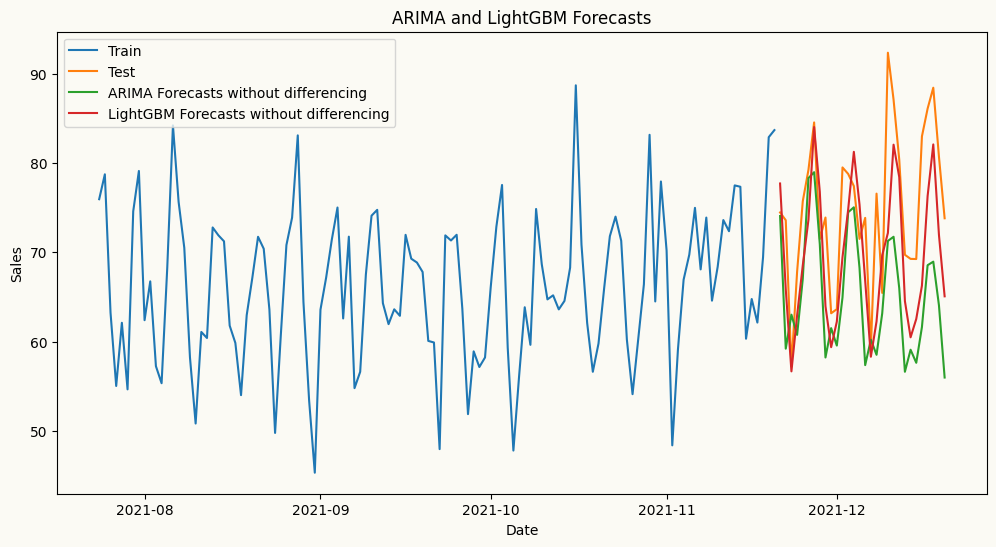

In [7]:
# arima forecast
arima_model = arima(target_col='sales', order=(2,0,0), seasonal_order=(1,0,0), seasonal_length=7)
arima_model.fit(train)
arima_forecast = arima_model.forecast(H=30)

# ml forecast using lightgbm
lgb_model = ml_forecaster(target_col='sales',model=LGBMRegressor(verbose=-1, n_estimators=100, learning_rate=0.1),
                          lags=7)
lgb_model.fit(train)
lgb_forecast = lgb_model.forecast(H=30)

# plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index[-120:], train['sales'][-120:], label='Train')
plt.plot(test.index, test['sales'], label='Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecasts without differencing')
plt.plot(test.index, lgb_forecast, label='LightGBM Forecasts without differencing')
plt.title('ARIMA and LightGBM Forecasts')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

As shown in the plot above, particularly, forecasts from the ARIMA model without differencing are underforecasting the upward trend in the data, resulting in forecasts that are significantly lower than the actual values. This highlights the importance of applying differencing to achieve stationarity when using ARIMA models, as it allows the model to capture the underlying patterns and trends in the data more effectively, leading to more accurate forecasts. Now, let's see how the forecasts look when we apply differencing for ARIMA.

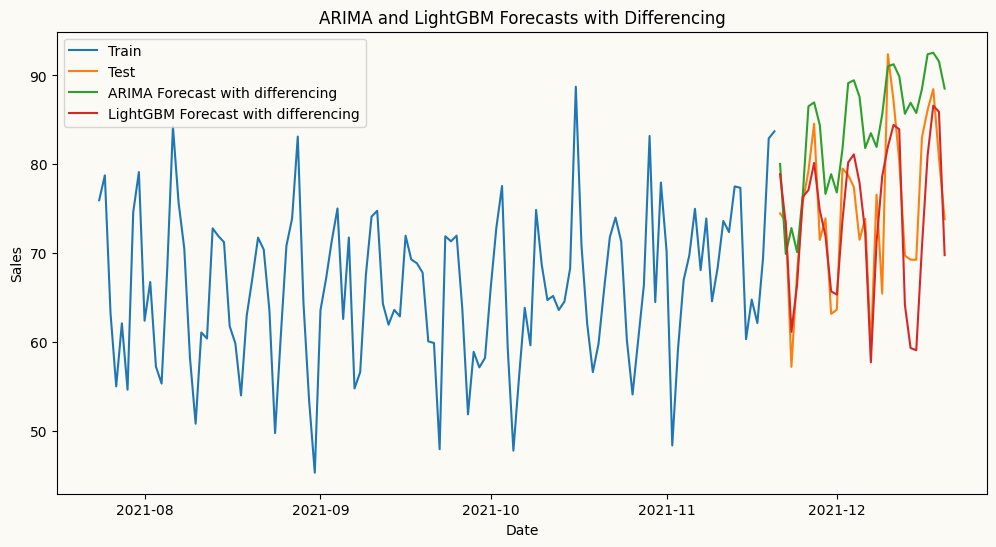

In [8]:
# arima forecast
arima_model = arima(target_col='sales', order=(2,1,0), seasonal_order=(1,0,0), seasonal_length=7)
arima_model.fit(train)
arima_forecast = arima_model.forecast(H=30)

# ml forecast using lightgbm
lgb_model = ml_forecaster(target_col='sales',model=LGBMRegressor(verbose=-1, n_estimators=100, learning_rate=0.1), lags=7, difference=1)
lgb_model.fit(train)
lgb_forecast = lgb_model.forecast(H=30)
# plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index[-120:], train['sales'][-120:], label='Train')
plt.plot(test.index, test['sales'], label='Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast with differencing')
plt.plot(test.index, lgb_forecast, label='LightGBM Forecast with differencing')
plt.title('ARIMA and LightGBM Forecasts with Differencing')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

When differencing is applied to strongly trending data, results can vary significantly across model families. LightGBM manages to track the trend reasonably well, while ARIMA overshoots considerably — because differencing removes the trend incrementally, and in the presence of a strong deterministic trend, this can inflate the model's variance and cause it to fit noise rather than signal, leading to poor out-of-sample performance.

This highlights an important practical consideration: differencing is not always the right tool for non-stationarity. When the trend is strong and smooth, more effective alternatives include detrending via linear regression, or piecewise linear regression when structural breaks are present. When the data also exhibits local seasonality or a time-varying trend, a better approach is to first fit an ETS model to capture those components, then apply ARIMA to the residuals.

### Trend removal via global detrending

Rather than differencing, we can detrend the series by fitting a linear regression to the original time series, extracting the underlying trend, and passing the residuals to ARIMA or ML regressors. This is a valid and often more stable approach to achieving stationarity when the trend is deterministic and approximately linear — the residuals are stationary by construction, and the forecasting model focuses purely on the remaining dynamics. peshbeen's detrending pipeline handles this automatically.

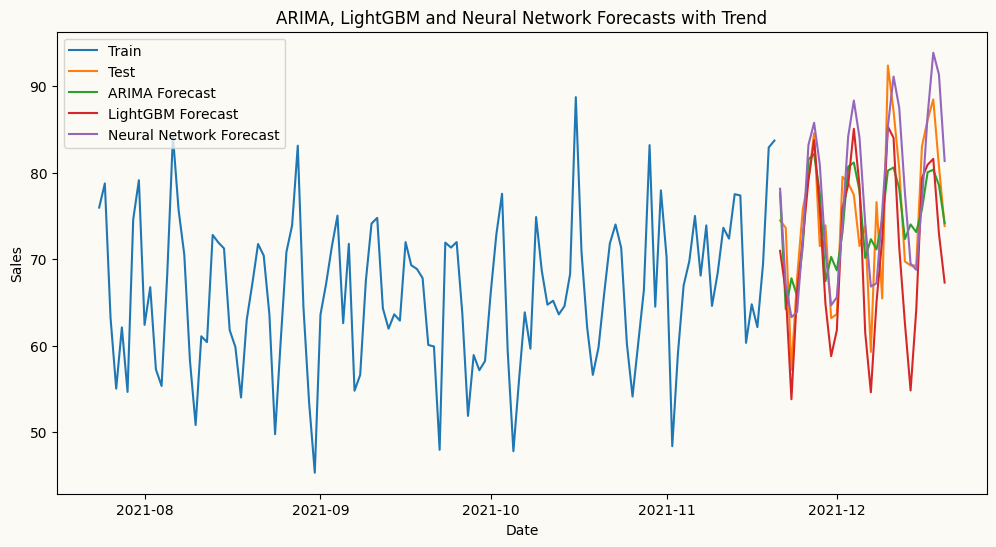

In [9]:
# arima forecast with linear detrending
arima_model = arima(target_col='sales', order=(2,0,0), seasonal_order=(1,0,0), seasonal_length=7, trend='linear')
arima_model.fit(train)
arima_forecast = arima_model.forecast(H=30)

# ml forecast using lightgbm with linear detrending
lgb_model = ml_forecaster(target_col='sales',model=LGBMRegressor(verbose=-1, n_estimators=100, learning_rate=0.1), lags=7, trend='linear')
lgb_model.fit(train)
lgb_forecast = lgb_model.forecast(H=30)

# ml forecast using neural network with linear detrending
from sklearn.neural_network import MLPRegressor
nn_model = ml_forecaster(target_col='sales',model=MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu', solver='adam', max_iter=200), lags=7, trend='linear')
nn_model.fit(train)
nn_forecast = nn_model.forecast(H=30)

# plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index[-120:], train['sales'][-120:], label='Train')
plt.plot(test.index, test['sales'], label='Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.plot(test.index, lgb_forecast, label='LightGBM Forecast')
plt.plot(test.index, nn_forecast, label='Neural Network Forecast')
plt.title('ARIMA, LightGBM and Neural Network Forecasts with Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In the plot above, we can see that the forecasts from the ARIMA, LightGBM and Neural Network models with detrending are much closer to the actual values and more unbiased compared to the forecasts without detrending. This demonstrates the effectiveness of detrending in improving the accuracy of forecasts from ARIMA and machine learning models when dealing with non-stationary time series data. By removing the underlying trend, the models can better capture the true patterns in the data, leading to more accurate and reliable forecasts.

### Trend removal via ETS (Error-Trend-Seasonality)


The trend may not always be linear, and the series may also exhibit a time-varying trend. In such cases, a more effective approach is to first fit an ETS model to capture the trend (or together with the seasonal component), then apply ARIMA or ML regressors to the residuals. This allows us to model the complex non-stationarity in the data more effectively, as the ETS model can capture the evolving trend and seasonal patterns, while the ARIMA or ML model focuses on modeling the remaining stationary residuals. peshbeen's pipeline automates this process, ensuring that the forecasting models are applied to stationary data for improved accuracy.

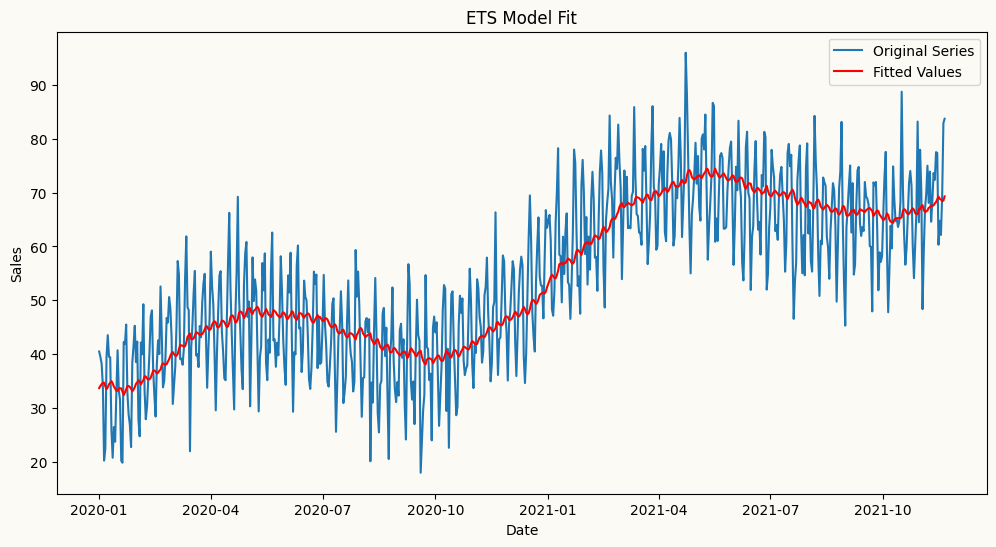

In [10]:
# We might need to use a more flexible trend model like ETS to capture the non-linear trend in the data. Let's fit an ETS model and plot the fitted values.
from statsmodels.tsa.holtwinters import ExponentialSmoothing
ets_model = ExponentialSmoothing(train['sales'], trend='add')
ets_model_fit = ets_model.fit(smoothing_level=0.05, smoothing_trend=0.001)
# plot the fitted values and the original series
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['sales'], label='Original Series')
plt.plot(train.index, ets_model_fit.fittedvalues, label='Fitted Values', color='red', linestyle='-')
plt.title('ETS Model Fit')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

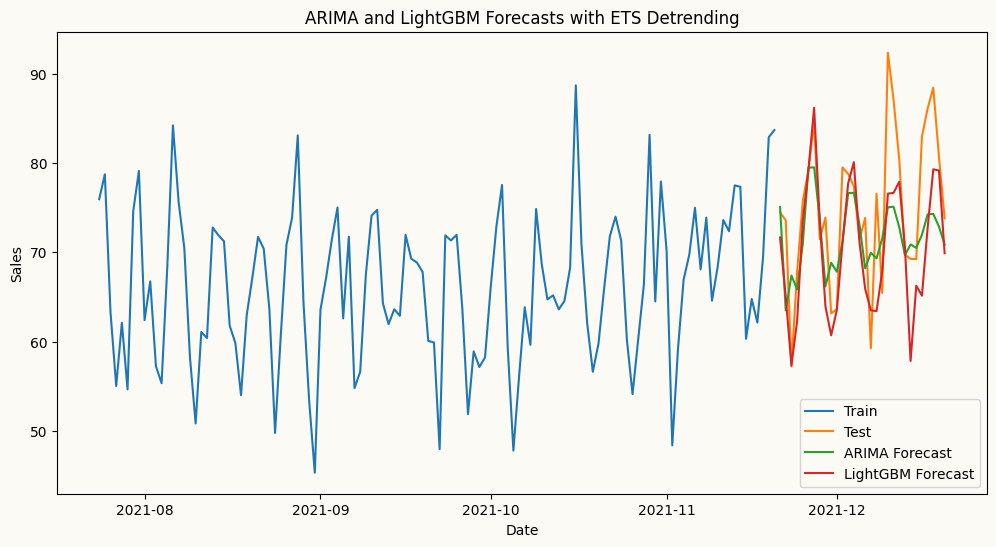

In [11]:
# arima forecast with ets detrending
arima_model = arima(target_col='sales', order=(2,0,0), seasonal_order=(1,0,0), seasonal_length=7,
                    trend='ets', ets_params={'trend': 'add','smoothing_level': 0.05, 'smoothing_trend': 0.001})
arima_model.fit(train)
arima_forecast = arima_model.forecast(H=30)

# ml forecast using lightgbm with ets detrending
lgb_model = ml_forecaster(target_col='sales',model=LGBMRegressor(verbose=-1, n_estimators=100,learning_rate=0.1),
                          lags=7, trend='ets', ets_params={'trend': 'add', 'smoothing_level': 0.05, 'smoothing_trend': 0.001})
lgb_model.fit(train)
lgb_forecast = lgb_model.forecast(H=30)

# plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index[-120:], train['sales'][-120:], label='Train')
plt.plot(test.index, test['sales'], label='Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.plot(test.index, lgb_forecast, label='LightGBM Forecast')
plt.title('ARIMA and LightGBM Forecasts with ETS Detrending')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

### Trend removal via Piecewise Linear Regression

Linear detrending assumes a single consistent trend across the entire series — but what if the trend shifts at some point? In such cases, piecewise linear regression is a more appropriate approach: given a known breakpoint, it fits separate linear trends to each segment. peshbeen's detrending pipeline supports this automatically, allowing both statistical and ML models to benefit from more accurate trend removal in the presence of structural breaks.

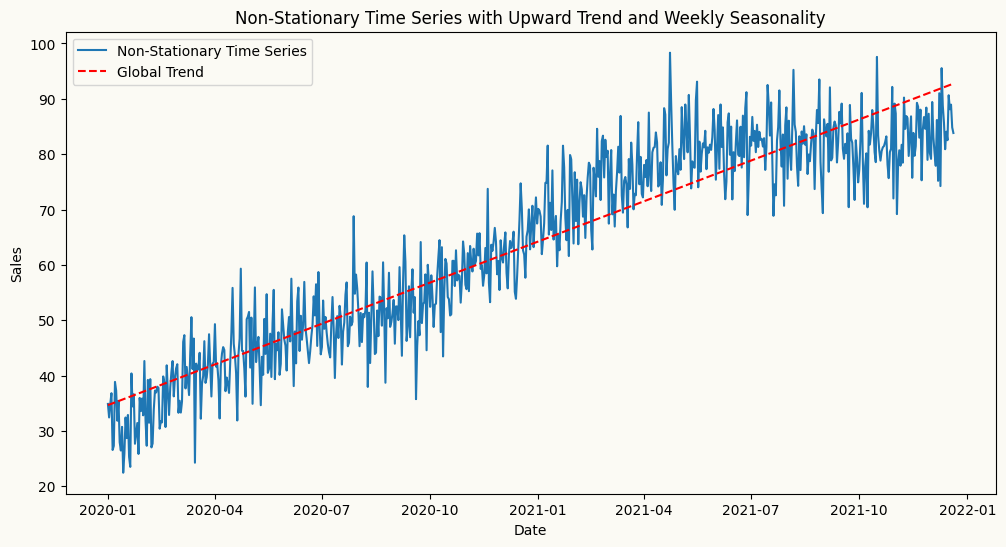

In [12]:
#| hide

date_range = pd.date_range(start='2020-01-01', periods=720, freq='D')
np.random.seed(42)

doy = date_range.dayofyear.to_numpy()  # force NumPy, not pandas Index

data = (
    30
    + 0.1 * np.arange(720)
    + 3 * np.sin(2 * np.pi * doy / 7)
    + 3 * np.sin(2 * np.pi * doy / 365)
    + np.random.normal(0, 5, 720)
)

# now mutable
data[520:] -= 0.08* np.arange(200)

sales_struct_ch = pd.DataFrame(data, index=date_range, columns=['sales'])

from sklearn.linear_model import LinearRegression
X = np.arange(len(sales_struct_ch)).reshape(-1, 1)
y = sales_struct_ch['sales'].values
model = LinearRegression()
model.fit(X, y)
trend_line = model.predict(X)

plt.figure(figsize=(12, 6))
plt.plot(sales_struct_ch.index, sales_struct_ch['sales'], label='Non-Stationary Time Series')
plt.plot(sales_struct_ch.index, trend_line, label='Global Trend', color='red', linestyle='--')
plt.title('Non-Stationary Time Series with Upward Trend and Weekly Seasonality')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

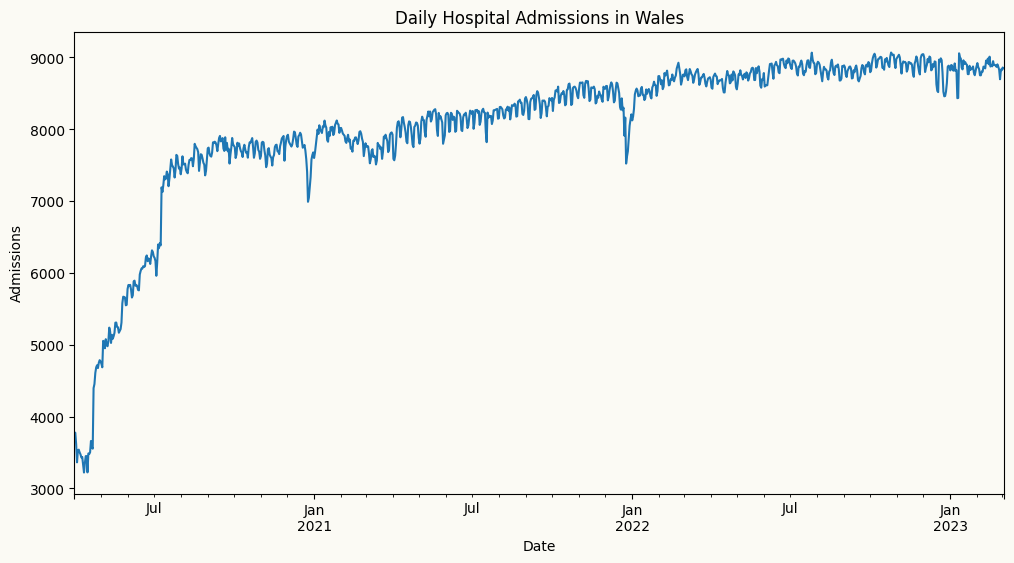

In [13]:
# lets explore the noisy wales hospital admissions dataset to see how piecewise linear regression can help with structural breaks in the trend. The dataset contains daily hospital admissions in Wales, and we know there was a significant structural break in the trend around March 2020 due to the COVID-19 pandemic. We will load the dataset and visualize the trend to identify the breakpoint.
from peshbeen.datasets import load_wales_admissions
load_wales_admissions["day_of_week"] = load_wales_admissions.index.dayofweek
load_wales_admissions["month"] = load_wales_admissions.index.month
cat_variables = ["day_of_week", "month"]
figure, ax = plt.subplots(figsize=(12,6))
load_wales_admissions["admissions"].plot(ax=ax)
ax.set_title("Daily Hospital Admissions in Wales")
ax.set_xlabel("Date")
ax.set_ylabel("Admissions")
plt.show()

Let's find the breakpoint using the pelt method from the `ruptures` library and `radial basis function` cost function, which is good for detecting changes in mean and variance.

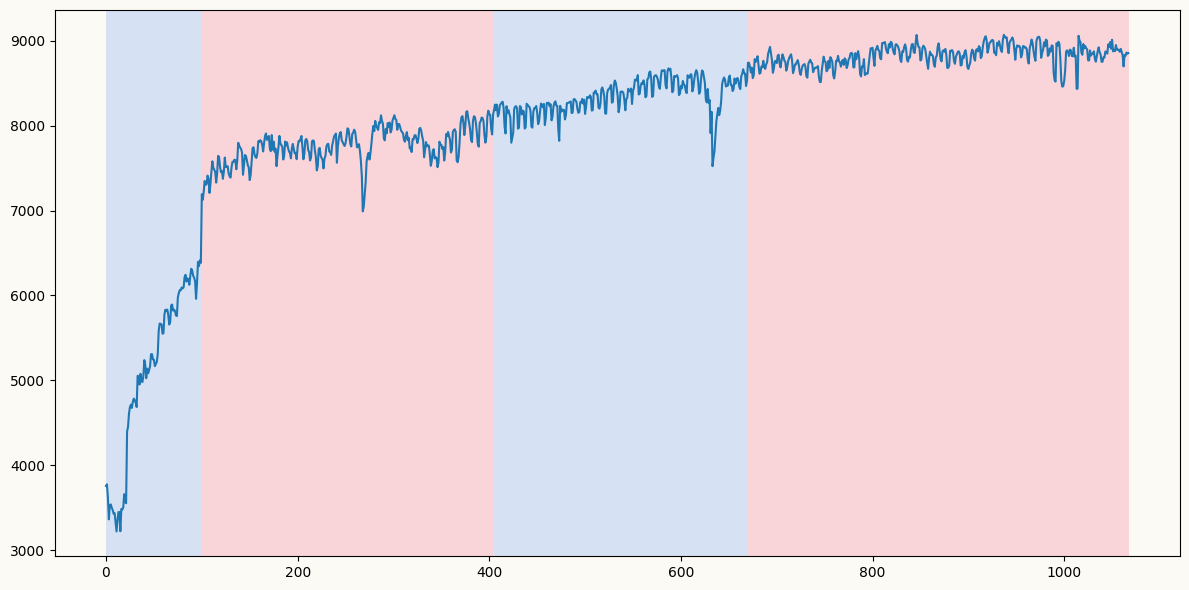

In [14]:

import ruptures as rpt
admis_array = load_wales_admissions["admissions"].values
change_det = rpt.Pelt(model="rbf").fit(admis_array)
result_rbf = change_det.predict(60) # higher penalty means fewer breakpoints, recommend trying other values to see which one captures the break better visually.
rpt.display(admis_array, result_rbf, figsize=(12, 6))
plt.show()

In [15]:
result_rbf # the detected breakpoints seem to be at indices 100 and 510 (the last one is at the end of the series, so we can ignore it)

[100, 405, 670, 1068]

Although change point detection methods suugest 2 breakpoints, it seems that the first one is more prevalent from the plot, which is around July 2020, when the relaxation of the first COVID-19 lockdown measures started in UK. By specifying this breakpoint in peshbeen's detrending pipeline, we can fit separate linear trends before and after the breakpoint, allowing for more accurate modeling of the underlying trend in the presence of structural breaks. This approach helps to capture the different dynamics in each segment of the series, leading to improved forecasting performance for both statistical and machine learning models.

First, we can visualize the original series along with the fitted piecewise linear trend to confirm that the breakpoint is correctly identified and that the piecewise linear regression captures the underlying trend effectively.

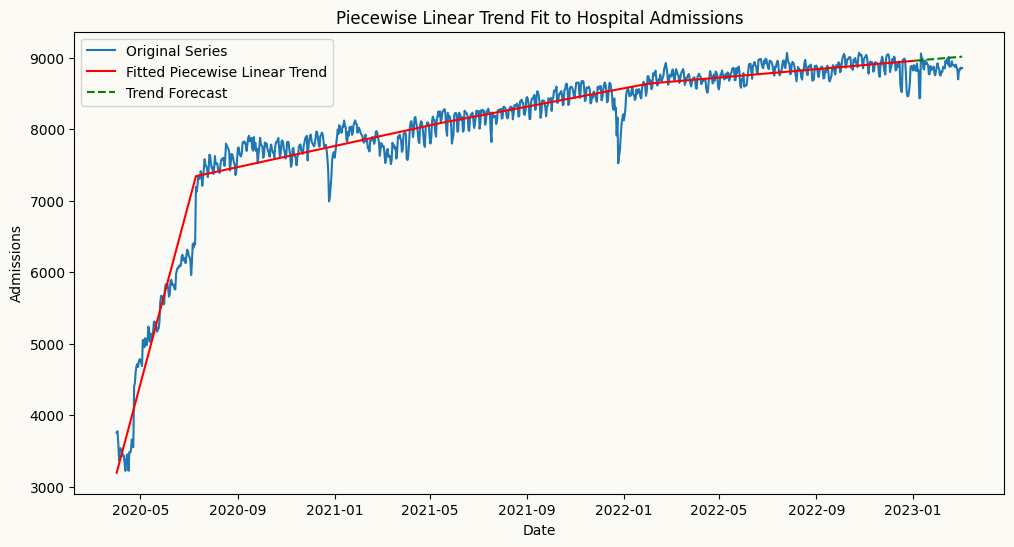

In [16]:
from peshbeen.statstools import lr_trend_model, forecast_trend
ch_points = result_rbf[:-1] # ignore the last breakpoint at the end of the series
train_admit_trend = load_wales_admissions.iloc[:-60]
test_admit_trend = load_wales_admissions.iloc[-60:]
fitted_trend, pw_model, _ = lr_trend_model(train_admit_trend["admissions"], breakpoints=ch_points, type="piecewise")
trend_forecast, _ = forecast_trend(model=pw_model, H=60, breakpoints=ch_points, start=train_admit_trend.shape[0])

# plot the original series and the fitted piecewise linear trend
plt.figure(figsize=(12, 6))
plt.plot(load_wales_admissions.index, load_wales_admissions['admissions'], label='Original Series')
plt.plot(load_wales_admissions.index[:-60], fitted_trend, label='Fitted Piecewise Linear Trend', color='red', linestyle='-')
plt.plot(test_admit_trend.index, trend_forecast, label='Trend Forecast', color='green', linestyle='--')
plt.title('Piecewise Linear Trend Fit to Hospital Admissions')
plt.xlabel('Date')
plt.ylabel('Admissions')
plt.legend()
plt.show()

The plot above shows the original non-stationary time series with an upward trend with breaks, along with the fitted piecewise linear trend (in red) that captures the structural break around July 2020. This visualization confirms that the piecewise linear regression is effectively modeling the changing trend in the data, allowing for more accurate detrending and improved forecasting performance for a model such as LGBMRegressor that is applied to the detrended series.

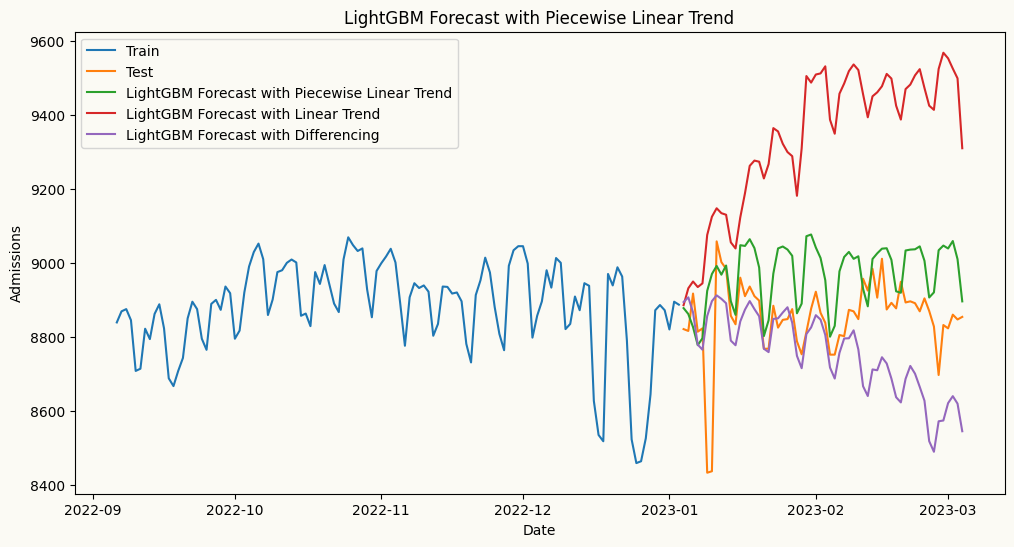

In [17]:
# forecasting model incorporating piecewise linear trend
pw_fmodel = ml_forecaster(model=LGBMRegressor(),
              target_col='admissions', lags = 7, cat_variables=cat_variables, trend="linear", change_points=ch_points) 
pw_fmodel.fit(train_admit_trend)
pw_forecasts = pw_fmodel.forecast(H=60, exog=test_admit_trend[cat_variables])

# forecasting model incorporating piecewise linear trend
lr_fmodel = ml_forecaster(model=LGBMRegressor(),
              target_col='admissions', lags = 7, cat_variables=cat_variables, trend="linear")
lr_fmodel.fit(train_admit_trend)
lr_forecasts = lr_fmodel.forecast(H=60, exog=test_admit_trend[cat_variables])

# Forecast using differencing to remove the trend
diff_fmodel = ml_forecaster(model=LGBMRegressor(),
              target_col='admissions', lags = 7, cat_variables=cat_variables, difference=1)
diff_fmodel.fit(train_admit_trend)
diff_forecasts = diff_fmodel.forecast(H=60, exog=test_admit_trend[cat_variables])

# plot the forecast and actuals
plt.figure(figsize=(12, 6))
plt.plot(train_admit_trend.index[-120:], train_admit_trend['admissions'][-120:], label='Train')
plt.plot(test_admit_trend.index, test_admit_trend['admissions'], label='Test')
plt.plot(test_admit_trend.index, pw_forecasts, label='LightGBM Forecast with Piecewise Linear Trend')
plt.plot(test_admit_trend.index, lr_forecasts, label='LightGBM Forecast with Linear Trend')
plt.plot(test_admit_trend.index, diff_forecasts, label='LightGBM Forecast with Differencing')
plt.title('LightGBM Forecast with Piecewise Linear Trend')
plt.xlabel('Date')
plt.ylabel('Admissions')
plt.legend()
plt.show()

From the plot above, we can see that the piecewise linear regression captures the future trend more accurately than both the global linear trend and differencing. The piecewise linear trend (in green) closely follows future values of the series, while the global linear trend (in red) overestimates the future trend, and the differenced series (in purple) underestimates it. This highlights the importance of using piecewise linear regression for detrending when there are structural breaks in the data, as it allows for more accurate modeling of the underlying trend and improved forecasting performance.

## Automatic Transformations

peshbeen supports user-specified rolling window features — such as rolling means and standard deviations — which can be particularly useful for ML regressors as they capture recent dynamics in the series. Beyond feature engineering, peshbeen can automatically apply a Box-Cox transformation to the target variable when the data exhibits heteroscedasticity, stabilising variance before model fitting and improving forecast reliability.

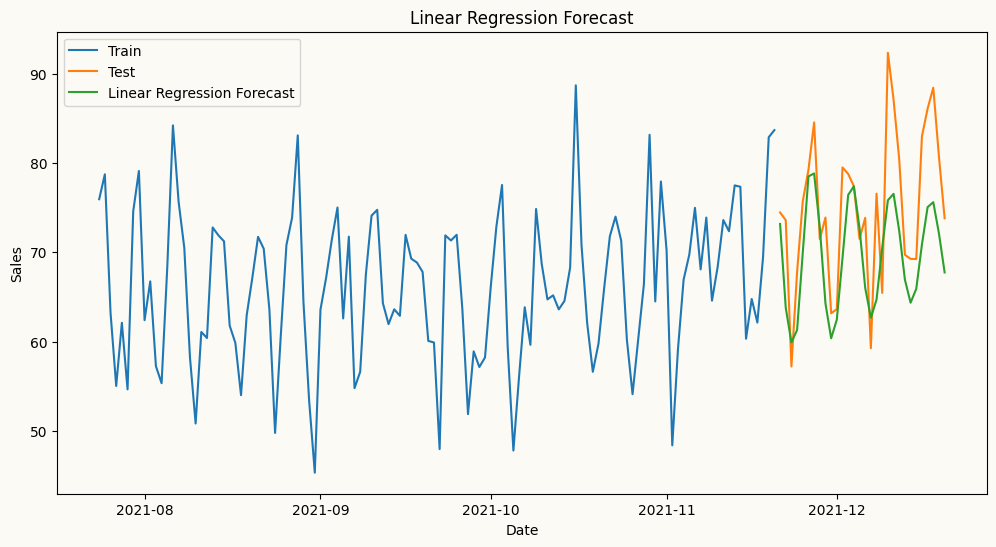

In [18]:
#| hide
from peshbeen.metrics import WMAPE, MAE, RMSE
from peshbeen.transformations import rolling_mean, rolling_quantile, rolling_std, expanding_mean, fourier_terms
from sklearn.linear_model import LinearRegression, Ridge
transformations = [rolling_std(window_size=30, shift=1), rolling_mean(window_size=30, shift=7),
                   rolling_quantile(window_size=30, shift=1, quantile=0.25),
                   rolling_quantile(window_size=30, shift=1, quantile=0.75), expanding_mean(shift=1)]
linear_model = ml_forecaster(model=LinearRegression(),
              target_col='sales', lags = 7, box_cox=0.5, lag_transform=transformations)
linear_model.fit(train)
# linear_model.data_prep(train)
forecasts = linear_model.forecast(H=30)

# plot the forecast and the actual values
plt.figure(figsize=(12, 6))
plt.plot(train.index[-120:], train['sales'][-120:], label='Train')
plt.plot(test.index, test['sales'], label='Test')
plt.plot(test.index, forecasts, label='Linear Regression Forecast')
plt.title('Linear Regression Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

For series with strong seasonal patterns, peshbeen can automatically generate Fourier terms as a DataFrame indexed to match the original series — making them ready to merge as exogenous variables in a single line. Calendar features such as month or day of week can be added directly to the same DataFrame, and peshbeen will automatically encode them as categorical variables. This covers a wide range of calendar effects, from weekend sales spikes to holiday demand shifts.

In [19]:
from peshbeen.transformations import fourier_terms
# create fourier terms for yearly seasonality with period 365 and number of terms 2 to be used as exogenous variables in the model
sales_exog = sales_data.copy() # create a copy of the original data to store the fourier terms
# create day of week
sales_exog['day_of_week'] = sales_exog.index.dayofweek
cat_vars = ['day_of_week']
fourier_trms = fourier_terms(start_end_index=(sales_data.index[0], sales_data.index[-1]), period=365, num_terms=2)
sales_exog = sales_exog.merge(fourier_trms, left_index=True, right_index=True) # merge the fourier terms with the original data to be used as exogenous variables in the model
sales_exog.head()

,sales,day_of_week,sin_1_365,sin_2_365,cos_1_365,cos_2_365
2020-01-01,40.474019,2,0.000000,0.000000,1.000000,1.000000
2020-01-02,39.472174,3,0.017213,0.034422,0.999852,0.999407
2020-01-03,38.233477,4,0.034422,0.068802,0.999407,0.997630
2020-01-04,34.174336,5,0.051620,0.103102,0.998667,0.994671
2020-01-05,20.219602,6,0.068802,0.137279,0.997630,0.990532


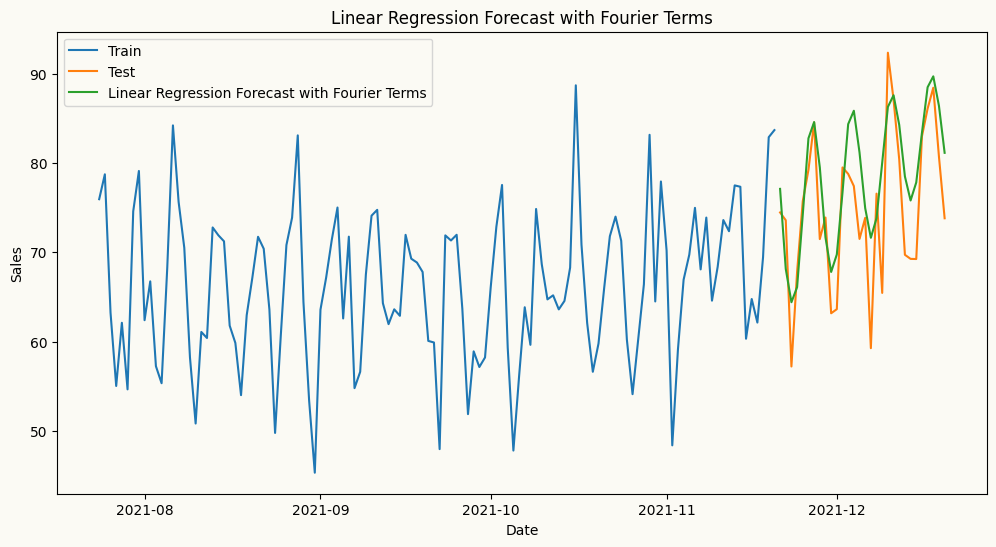

In [20]:
# split the data into train and test
train_exog = sales_exog.iloc[:-30]
test_exog = sales_exog.iloc[-30:].drop(columns=['sales']) # drop the target column from the exogenous variables for the test set
# ml forecast using Linear Regression with fourier terms as exogenous variables
lr_model = ml_forecaster(model=LinearRegression(),
              target_col='sales', lags = 7, box_cox=0.5, lag_transform=transformations)
lr_model.fit(train_exog)
lr_forecast = lr_model.forecast(H=30, exog=test_exog)
# plot the forecast and the actual values
plt.figure(figsize=(12, 6))
plt.plot(train.index[-120:], train['sales'][-120:], label='Train')
plt.plot(test.index, test['sales'], label='Test')
plt.plot(test.index, lr_forecast, label='Linear Regression Forecast with Fourier Terms')
plt.title('Linear Regression Forecast with Fourier Terms')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

## Probabilistic Forecasting

peshbeen provides native support for probabilistic forecasting, allowing users to obtain not only point forecasts but also prediction intervals and full forecast scenarios. For any model in the library, prediction intervals are generated by calibrating the model's residuals on a held-out calibration set, then using those calibrated residuals to simulate future paths of the series — giving a realistic picture of forecast uncertainty rather than a single optimistic trajectory.
peshbeen supports four calibration methods: bootstrapping, correlated error bootstrapping, KDE-based sampling, and conformal prediction. The first three support both prediction intervals and scenario generation; conformal prediction is limited to prediction intervals only.

In [21]:
from peshbeen.probabilistic_forecasting import prob_forecasts

# lets use our sales_exog dataset to generate probabilistic forecasts using the linear regression model we fitted with fourier terms as exogenous variables. We will use the bootstrapping method to generate prediction intervals and forecast scenarios, which will allow us to capture the uncertainty in our forecasts and provide a range of possible future outcomes based on the variability in the historical data. This approach is particularly useful for decision-making and risk assessment, as it gives us insights into the potential variability in future sales rather than just a single point forecast. We will then visualize the prediction intervals and scenarios to better understand the uncertainty around our forecasts.
# first create a model instance with the same specifications as the one we used to generate point forecasts, but without fitting it yet
lr_model = ml_forecaster(model=LinearRegression(),
              target_col='sales', lags = 7, box_cox=0.5, lag_transform=transformations)
# lr_model.fit(train_exog)
prob_model = prob_forecasts(model=lr_model, H=30, n_calibration=150, step_size=1, random_state=42)
## Generate 1000 forecast scenarios using the KDE-based sampling method, which will allow us to capture the uncertainty in our forecasts and provide a range of possible future outcomes based on the variability in the historical data. We will use the exogenous variables from the test set to generate these scenarios, which will help us understand how different future paths of the series can evolve given the uncertainty in the data and the model.
prob_samples = prob_model.sample(df=train_exog, n_samples=1000, method="empirical", future_exog=test_exog)
# other options for method are "bootstrap" and "correlated_bootstrap" for both prediction intervals and scenarios, and "conformal" for prediction intervals only. Each method has its own assumptions and characteristics, so it's recommended to try different methods to see which one captures the uncertainty in the forecasts better for your specific dataset and use case.
# prob_samples = prob_model.sample(df=train_exog, n_samples=1000, method="empirical", future_exog=test_exog) # bootstrap method, which resamples the residuals with replacement to generate forecast scenarios, allowing us to capture the variability in the historical data and provide a range of possible future outcomes based on the empirical distribution of the residuals. This method is straightforward and does not make strong assumptions about the distribution of the residuals, making it a popular choice for generating probabilistic forecasts. By using the exogenous variables from the test set, we can also account for any future changes in those variables that may impact the forecasts, providing a more realistic picture of potential future scenarios.
# prob_samples = prob_model.sample(df=train_exog, n_samples=1000, method="correlated", future_exog=test_exog) # correlated error bootstrap method, which resamples the residuals while preserving their correlation structure to generate forecast scenarios, allowing us to capture the variability in the historical data and provide a range of possible future outcomes based on the empirical distribution of the residuals while also accounting for any correlation between them. This method is particularly useful when there is autocorrelation in the residuals, as it helps to maintain the temporal dependence structure in the generated scenarios. By using the exogenous variables from the test set, we can also account for any future changes in those variables that may impact the forecasts, providing a more realistic picture of potential future scenarios.

In [22]:
scenarios_df = prob_samples.sample_paths_df
scenarios_df.head()

,h_1,h_2,h_3,h_4,h_5,h_6,h_7,h_8,h_9,h_10,...,h_21,h_22,h_23,h_24,h_25,h_26,h_27,h_28,h_29,h_30
0,72.165124,65.018523,58.685749,47.420708,81.279949,78.333260,88.188117,69.510644,68.792562,60.274080,...,85.571182,80.263417,77.919869,69.087373,73.394922,74.102220,89.969702,85.155077,91.032894,84.363991
1,78.740224,73.656020,62.663265,82.622615,85.944303,88.852087,92.977028,80.017621,66.718696,69.113825,...,77.575026,78.897084,69.321855,71.745364,76.605013,65.300697,88.770881,85.458114,82.487316,84.679443
2,82.865650,62.281532,65.304187,65.331266,70.348363,80.779403,80.521614,70.073849,69.600784,67.162420,...,92.211786,73.136868,79.035069,80.401879,74.340930,80.416744,89.452769,71.938916,82.001587,77.755432
3,81.018377,62.479665,60.903477,64.875202,71.601721,81.967842,78.385867,85.718087,76.031497,67.571418,...,79.727420,79.749076,72.321027,71.745364,72.292976,90.925367,78.021837,94.461588,78.959175,77.901390
4,69.928576,62.803454,62.471068,67.851924,62.016128,84.764587,75.904103,67.156488,72.664487,54.334784,...,77.388138,70.125829,81.704687,72.732145,61.298774,86.924251,81.497837,86.758289,88.904046,86.690104


In [23]:
# we can also generate prediction intervals from the generated scenarios using the sample_quantiles attribute of the prob_samples object, which gives us the quantiles of the simulated forecast paths and allows us to visualize the uncertainty around our forecasts in the form of prediction intervals.
prediction_intervals = prob_samples.sample_quantiles(quantiles=[0.1, 0.9])
prediction_intervals.head()

,point_forecast,q_10,q_90
0,77.122920,69.698135,82.865650
1,68.146032,60.002076,75.434542
2,64.408363,56.248948,71.702888
3,66.099967,57.453921,73.256741
4,74.238540,64.462217,81.958753


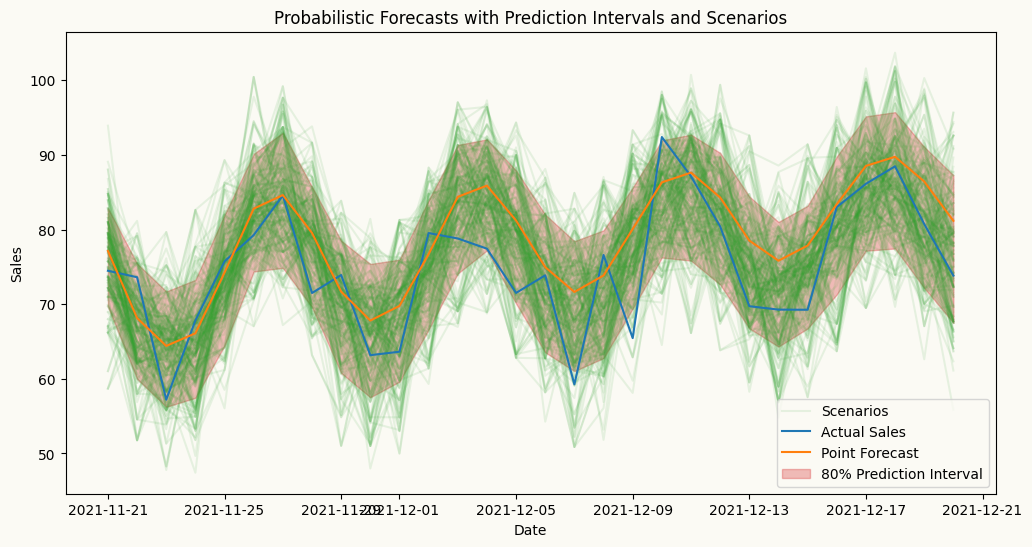

In [24]:
# lets visualize the prediction intervals and 15 scenarios from the generated probabilistic forecasts to understand the uncertainty around our forecasts and the range of possible future outcomes based on the variability in the historical data. This visualization will help us see how the forecasted values can vary and provide insights into potential risks and opportunities for decision-making.
plt.figure(figsize=(12, 6))
# plot 201 scenarios
for i in range(200):
    plt.plot(test.index, scenarios_df.iloc[i], color='C2', alpha=0.1)
plt.plot(test.index, scenarios_df.iloc[100], color='C2', alpha=0.1, label='Scenarios') # added for labeling the scenarios in the legend
plt.plot(test.index, test['sales'], label='Actual Sales', color='C0')
plt.plot(test.index, lr_forecast, label='Point Forecast', color='C1')
# plot the prediction intervals we generated from the scenarios
plt.fill_between(test.index, prediction_intervals["q_10"], prediction_intervals["q_90"], color='C3', alpha=0.3, label='80% Prediction Interval')
plt.title('Probabilistic Forecasts with Prediction Intervals and Scenarios')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

One concern with bootstrapping residuals is that it assumes the residuals are independent and identically distributed (i.i.d.), which may not hold in time series data where residuals can exhibit autocorrelation. To address this, peshbeen offers correlated error bootstrapping, which preserves the temporal dependence structure of the residuals by resampling blocks of consecutive residuals rather than individual residuals. This method may provide more accurate prediction intervals and scenarios when there is significant autocorrelation in the residuals.

Also, KDE-based sampling allows for a non-parametric estimation of the residual distribution, which can capture more complex patterns in the residuals compared to simple bootstrapping. This can lead to more accurate and realistic forecast scenarios, especially when the residuals exhibit non-normality or heteroscedasticity.

To obtain probabilistic forecasts via correlated error bootstrapping and KDE-based sampling, user can simply pass `method="correlated"` or `method="kde"` to the `sample` method of the `prob_forecasts` object, along with the training and future exogenous variables if applicable.

### Conformal Prediction

Conformal prediction is a powerful technique for generating valid prediction intervals without making strong assumptions about the underlying data distribution. This method is particularly useful when the residuals do not follow a normal distribution or when there is heteroscedasticity in the data, as it provides robust and reliable prediction intervals based on the empirical distribution of the residuals. As conformal prediction does not rely on bootstrapping or density estimation, it does not support scenario generation, but it can be a valuable tool for obtaining accurate prediction intervals.

We can call `.conformal_quantiles` after `sample` to obtain conformal prediction intervals for the desired quantiles, which will be based on the empirical distribution of the residuals from the calibration set. But since conformal prediction does not support scenario generation, we do not need to first call `sample`. Instead, we can first calibrate the model using the `calibrate` method, which will compute the residuals on the calibration set and store them for later use in conformal prediction. Then, we can call `.conformal_quantiles` directly to obtain the prediction intervals for the specified quantiles, without needing to generate forecast scenarios.

In [25]:
lr_model = ml_forecaster(model=LinearRegression(),
              target_col='sales', lags = 7, box_cox=0.5, lag_transform=transformations)
# lr_model.fit(train_exog)
prob_model = prob_forecasts(model=lr_model, H=30, n_calibration=150, step_size=1, random_state=42)
# 
prob_model.calibrate(df=train_exog)
conformal_predictions = prob_model.conformal_quantiles(df=train_exog, quantiles=[0.1, 0.9], future_exog=test_exog)
conformal_predictions.head()

,point_forecast,q_10,q_90
0,77.122920,69.739454,84.506386
1,68.146032,60.321753,75.970312
2,64.408363,56.537655,72.279070
3,66.099967,58.012398,74.187536
4,74.238540,66.276437,82.200644


> What if there isn't enough data to set aside a separate calibration set? In that case, in-sample residuals can be used instead — but with an important caveat: since the model is evaluated on the data it was trained on, the resulting prediction intervals will likely be optimistic, underestimating true forecast uncertainty. This is particularly true when the model overfits, as in-sample residuals will not fully reflect the variability the model will encounter on unseen data. That said, it is a practical and computationally efficient option when data is limited, as it avoids holding out any observations from training.


> Note that correlated error bootstrapping is not available for in-sample residuals, as its procedure relies on horizon-dependent error structure that cannot be derived from in-sample fit alone.

In [26]:
lr_model = ml_forecaster(model=LinearRegression(),
              target_col='sales', lags = 7, box_cox=0.5, lag_transform=transformations)
prob_model_insample = prob_forecasts(model=lr_model, H=30, n_calibration=None, random_state=42) # Just leave n_calibration as None to use the training data for calibration
prob_samples = prob_model_insample.sample(df=train_exog, n_samples=1000, method="kde", future_exog=test_exog)

prob_samples.sample_quantiles(quantiles=[0.1, 0.9]).head()

,point_forecast,q_10,q_90
0,77.122920,69.658327,83.749231
1,68.146032,60.681439,74.772343
2,64.408363,56.943770,71.034674
3,66.099967,58.635374,72.726278
4,74.238540,66.773947,80.864851


## Hyperparameter Tuning

peshbeen provides two powerful tools for hyperparameter tuning: `hyperopt_tune` and `optuna_tune`. These functions allow you to optimize the hyperparameters of your forecasting models using the Hyperopt and Optuna libraries, respectively. Both functions support cross-validation and can be used with any of the forecasting models available in peshbeen.

In [27]:
from peshbeen.model_selection import hyperopt_tune, optuna_tune, mv_hyperopt_tune, mv_optuna_tune

In [28]:
#| hide

from peshbeen.datasets import load_wales_admissions
from peshbeen.metrics import WMAPE, MAE, RMSE
load_wales_admissions["day_of_week"] = load_wales_admissions.index.dayofweek
load_wales_admissions["month"] = load_wales_admissions.index.month
# split the data into train and test sets
train = load_wales_admissions[:-30]
test = load_wales_admissions[-30:]
cat_variables = ["day_of_week", "month"]
# import linear regression from sklearn
from sklearn.linear_model import LinearRegression
ml_model = ml_forecaster(model=LGBMRegressor(verbose=-1),
              target_col='admissions', lags = 30,
              cat_variables=cat_variables)
ml_model.fit(train)
# ml_model.data_prep(train)
forecasts = ml_model.forecast(H=30, exog=test[cat_variables])
lgb_param_space = {
    "learning_rate":     lambda t: t.suggest_float("learning_rate", 0.001, 0.6),
    "num_leaves":        lambda t: t.suggest_int("num_leaves", 10, 200),
    "max_depth":         lambda t: t.suggest_int("max_depth", 2, 18),
    "bagging_fraction":  lambda t: t.suggest_float("bagging_fraction", 0.5, 1.0),
    "feature_fraction":  lambda t: t.suggest_float("feature_fraction", 0.5, 1.0),
    "min_data_in_leaf":  lambda t: t.suggest_int("min_data_in_leaf", 5, 100),
    "lambda_l2":         lambda t: t.suggest_float("lambda_l2", 0.0, 10.0),
    "lambda_l1":         lambda t: t.suggest_float("lambda_l1", 0.0, 10.0),
    "min_gain_to_split": lambda t: t.suggest_float("min_gain_to_split", 0.0, 20.0),
    "max_bin":           lambda t: t.suggest_int("max_bin", 100, 350),
    "top_rate":          lambda t: t.suggest_float("top_rate", 0.05, 0.4),
    "other_rate":        lambda t: t.suggest_float("other_rate", 0.05, 0.3),
    "num_iterations":    lambda t: t.suggest_int("num_iterations", 30, 700),
    "top_k":             lambda t: t.suggest_int("top_k", 8, 30),
    "lags":              lambda t: t.suggest_categorical(
                             "lags", [
                                 (1,2,3,4,5),
                                 (1,4,7),
                                 (1,2,3,4,5,6,7),
                                 (1,2,3,4,5,6,7,14),
                                 (1,2,3,4,5,6,7,14,21),
                                 (1,2,3),
                             ]),
                             
    "seed":              lambda t: 0,   # fixed, not sampled
}

best_params, best_lags, other_ = optuna_tune(
    model=ml_model,
    df=train,
    cv_split=10,
    step_size=10,
    test_size=30,
    eval_metric=RMSE,
    eval_num=4,
    param_space=lgb_param_space, verbose=False
)

In [29]:
#| hide

ets_param_space = {
    "smoothing_level":     lambda t: t.suggest_float("smoothing_level", 0.001, 0.99),
    "trend":              lambda t: t.suggest_categorical(
                             "trend", [
                                 "add",
                                 "mul",
                                 None
                             ]),
    "seasonal":           lambda t: t.suggest_categorical(
                             "seasonal", [
                                 "add",
                                 "mul",
                                 None
                             ]),
    "smoothing_trend":    lambda t: t.suggest_float("smoothing_trend", 0.001, 0.99),
    "smoothing_seasonal": lambda t: t.suggest_float("smoothing_seasonal", 0.001, 0.99),
    "smoothing_level":     lambda t: t.suggest_float("smoothing_level", 0.001, 0.99),
    "seasonal_periods":              lambda t: 7,   # fixed, not sampled
}

ets_model = ets(target_col='admissions')
best_params, _, other_ = optuna_tune(
    model=ets_model,
    df=train,
    cv_split=4,
    step_size=1,
    test_size=30,
    eval_metric=RMSE,
    eval_num=100,
    param_space=ets_param_space, verbose=False
)

In [30]:
ets_model = ets(target_col='admissions', **best_params)

In [31]:
#| hide
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, space_eval
from hyperopt.pyll import scope

ml_model = ml_forecaster(model=LGBMRegressor(verbose=-1),
              target_col='admissions', lags = 30,
              cat_variables=cat_variables)
ml_model.fit(train)

lgb_param_space={'learning_rate': hp.uniform('learning_rate', 0.001, 0.6),
            'num_leaves': scope.int(hp.quniform('num_leaves', 10, 200, 1)),
           'max_depth':scope.int(hp.quniform('max_depth', 2, 18, 1)),
            'bagging_fraction': hp.uniform('bagging_fraction', 0.5, 1),
            'feature_fraction': hp.uniform('feature_fraction', 0.5, 1),
           'min_data_in_leaf': scope.int(hp.quniform ('min_data_in_leaf', 5, 100, 1)), 
            'lambda_l2' : hp.uniform('lambda_l2', 0,10),
           'lambda_l1' : hp.uniform('lambda_l1', 0, 10),
            'min_gain_to_split':hp.uniform('min_gain_to_split', 0, 20),
            "max_bin": scope.int(hp.quniform('max_bin', 100, 350, 1)),
           'top_rate' : hp.quniform('top_rate', 0.05, 0.4, 0.0001),
            'other_rate' : hp.quniform('other_rate', 0.05, 0.3, 0.0001),
           'num_iterations': scope.int(hp.quniform("num_iterations", 30, 700, 1)),
           'top_k': scope.int(hp.quniform('top_k', 8, 30, 1)),
           'lags': hp.choice("lags", [[1,2,3,4,5], [1,4,7], [1,2,3,4,5,6,7], [1,2,3,4,5,6,7,14], [1,2,3,4,5,6,7,14,21], [1,2,3]]),
                "seed":0}
best_hyperopt, best_hyperlag, other_ = hyperopt_tune(model=ml_model, df=train, cv_split=5, step_size=10,
                                        test_size=30, eval_metric=RMSE, eval_num=4,
                                        param_space=lgb_param_space)

100%|██████████| 4/4 [00:02<00:00,  1.76trial/s, best loss: 415.90263618485113]


## Multivariate Forecasting

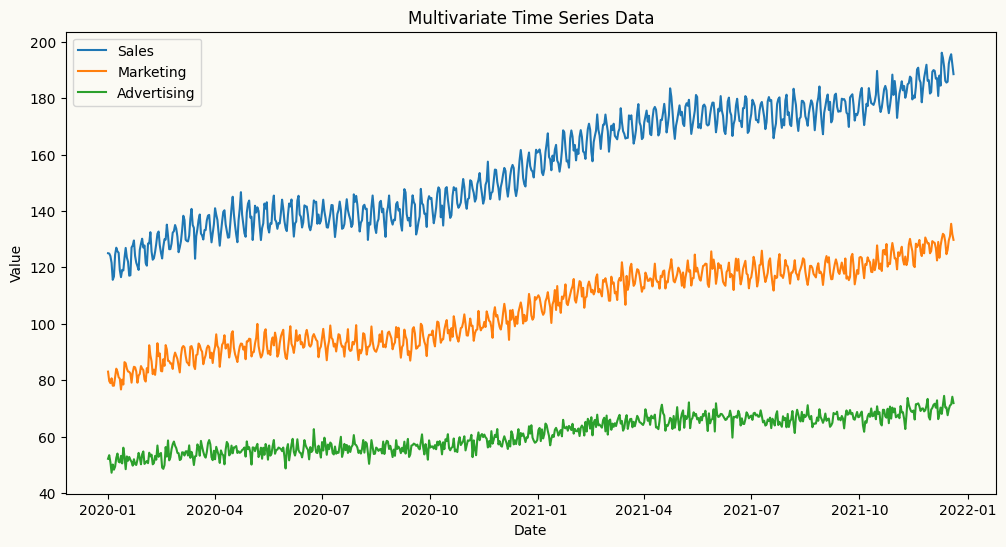

In [32]:
## Create a multivariate autoregressive sales data with 3 features: sales, marketing spend, and advertising spend to show if we can capture the relationships between past values of all three features to forecast the future values of sales. 
date_range = pd.date_range(start='2020-01-01', periods=720, freq='D')
np.random.seed(42)
doy = date_range.dayofyear.to_numpy()  # force NumPy, not pandas Index
data1 = 120 + 0.1 * np.arange(720) + 5 * np.sin(2 * np.pi * doy / 7) + 6 * np.sin(2 * np.pi * doy / 365) + np.random.normal(0, 2, 720)
data2 = 80 + 0.07 * np.arange(720) + 3 * np.sin(2 * np.pi * doy / 7) + 4 * np.sin(2 * np.pi * doy / 365) + np.random.normal(0, 2, 720)
data3 = 50 + 0.03 * np.arange(720) + 1 * np.sin(2 * np.pi * doy / 7) + 2 * np.sin(2 * np.pi * doy / 365) + np.random.normal(0, 2, 720)
multivariate_data = pd.DataFrame({'sales': data1, 'marketing': data2, 'advertising': data3}, index=date_range)

## add the day of week and month as categorical variables to the multivariate dataset
multivariate_data["day_of_week"] = multivariate_data.index.dayofweek
multivariate_data["month"] = multivariate_data.index.month

# plot the multivariate data
plt.figure(figsize=(12, 6))
plt.plot(multivariate_data.index, multivariate_data['sales'], label='Sales')
plt.plot(multivariate_data.index, multivariate_data['marketing'], label='Marketing')
plt.plot(multivariate_data.index, multivariate_data['advertising'], label='Advertising')
plt.title('Multivariate Time Series Data')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

In [33]:

from peshbeen.models import var, ml_forecaster
#split the data into train and test sets 
mv_train_data = multivariate_data.iloc[:-60]
mv_test_data = multivariate_data.iloc[-60:]

var_model =var(target_cols=['sales', 'marketing', 'advertising'], lags={'sales': 7, 'marketing': 7, 'advertising': 7}, cat_variables=['day_of_week', 'month'])
var_model.fit(mv_train_data)
var_forecasts = var_model.forecast(H=60, exog=mv_test_data[['day_of_week', 'month']])

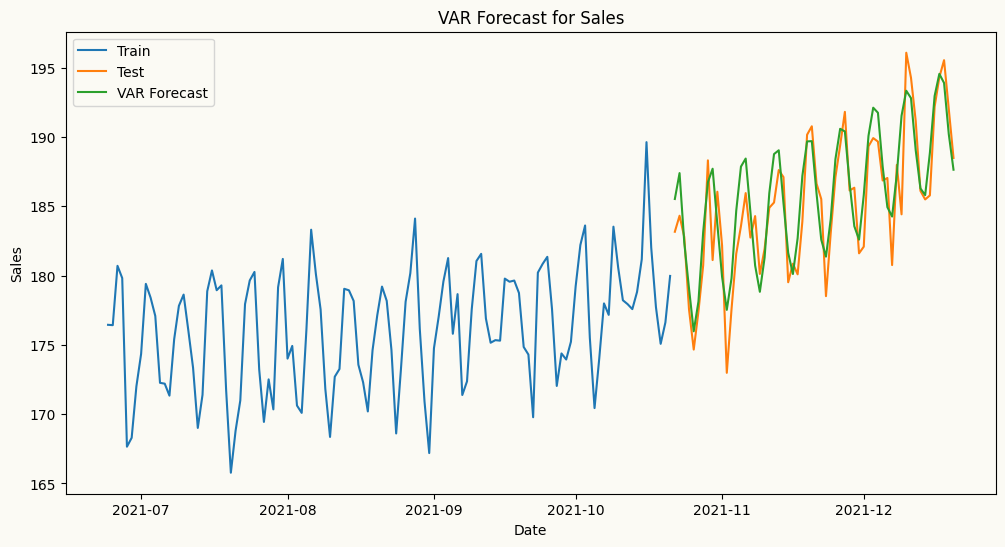

In [34]:
# plot the forecasts and the actual values for sales
plt.figure(figsize=(12, 6))
plt.plot(mv_train_data.index[-120:], mv_train_data['sales'][-120:], label='Train')
plt.plot(mv_test_data.index, mv_test_data['sales'], label='Test')
plt.plot(mv_test_data.index, var_forecasts['sales'], label='VAR Forecast')
plt.title('VAR Forecast for Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()